# Chapter 113 — Geometric Composition

> **Prerequisites:** ch109–112 (Rotation, Scaling, Reflection, Translation)
>
> **Outcomes:** Compose multiple transformations by matrix multiplication; Understand order dependence; Compute the inverse of a composition


## Composition as Matrix Multiplication

Applying T₁ then T₂ = applying the composed transformation T = T₂ · T₁.

In homogeneous coordinates, every transformation is a 3×3 matrix.
Composing n transformations = multiplying n matrices:
T_total = Tₙ · ... · T₂ · T₁

**Order matters critically.** Rotate then translate ≠ translate then rotate.

**Intuition:** Matrix multiplication is not commutative (A·B ≠ B·A in general).
For transformations: the last matrix applied is leftmost in the product.

**Inverse of a composition:** (T₂·T₁)⁻¹ = T₁⁻¹·T₂⁻¹
Undo in reverse order.

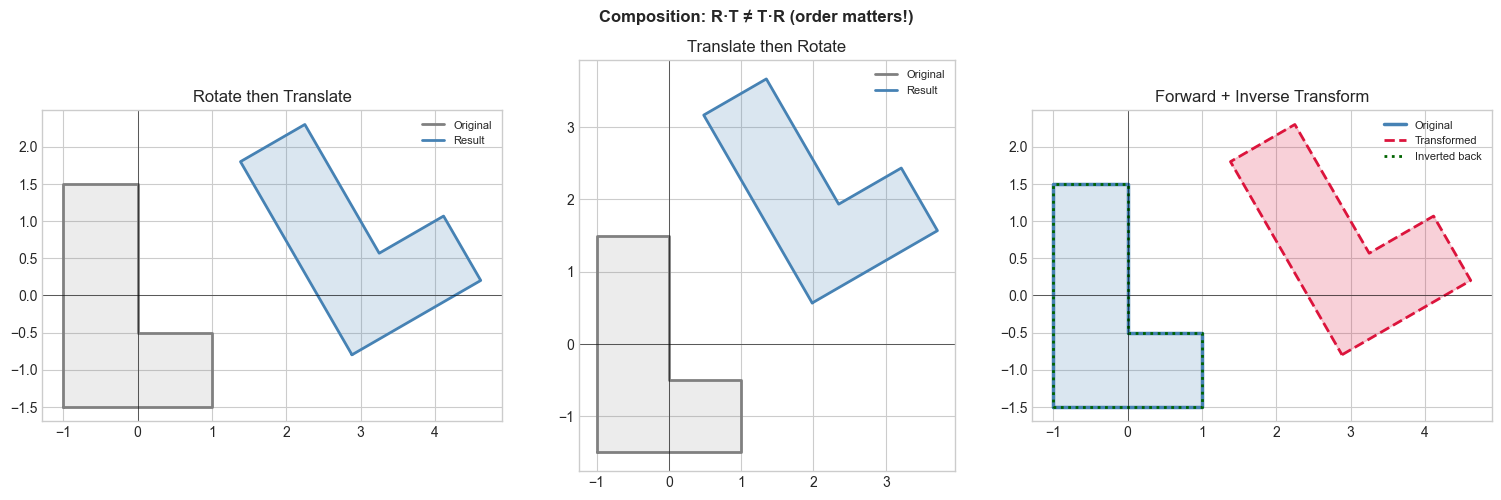

In [2]:
# --- Transformation composition ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def T_mat(dx,dy): return np.array([[1,0,dx],[0,1,dy],[0,0,1]],dtype=float)
def R_mat(theta):
    c,s=np.cos(theta),np.sin(theta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]],dtype=float)
def S_mat(sx,sy): return np.array([[sx,0,0],[0,sy,0],[0,0,1]],dtype=float)

def apply_h(M, pts):
    pts_h = np.hstack([pts, np.ones((len(pts),1))])
    out = (M @ pts_h.T).T
    return out[:,:2] / out[:,2:3]

# L-shaped polygon (origin-centered)
L = np.array([[0,0],[2,0],[2,1],[1,1],[1,3],[0,3],[0,0]],dtype=float) - np.array([1,1.5])

theta = np.radians(30)
dx, dy = 3, 1

# Rotate THEN translate
RT = T_mat(dx,dy) @ R_mat(theta)  # T applied after R
# Translate THEN rotate
TR = R_mat(theta) @ T_mat(dx,dy)  # R applied after T

fig, axes = plt.subplots(1,3,figsize=(15,5))
closed = lambda p: np.vstack([p,p[0]])

for ax, (M, name) in zip(axes[:2], [(RT,'Rotate then Translate'),(TR,'Translate then Rotate')]):
    result = apply_h(M, L)
    ax.fill(L[:,0],L[:,1],alpha=0.15,color='gray')
    ax.plot(closed(L)[:,0],closed(L)[:,1],'gray',lw=2,label='Original')
    ax.fill(result[:,0],result[:,1],alpha=0.2,color='steelblue')
    ax.plot(closed(result)[:,0],closed(result)[:,1],'steelblue',lw=2,label='Result')
    ax.set_aspect('equal'); ax.legend(fontsize=8); ax.set_title(name)
    ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)

# Inverse
ax = axes[2]
M_fwd = RT
M_inv = np.linalg.inv(M_fwd)
result_fwd = apply_h(M_fwd, L)
result_back = apply_h(M_inv, result_fwd)

ax.fill(L[:,0],L[:,1],alpha=0.2,color='steelblue')
ax.plot(closed(L)[:,0],closed(L)[:,1],'steelblue',lw=2.5,label='Original')
ax.fill(result_fwd[:,0],result_fwd[:,1],alpha=0.2,color='crimson')
ax.plot(closed(result_fwd)[:,0],closed(result_fwd)[:,1],'crimson',lw=2,linestyle='--',label='Transformed')
ax.plot(closed(result_back)[:,0],closed(result_back)[:,1],'darkgreen',lw=2,linestyle=':',label='Inverted back')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.set_title('Forward + Inverse Transform')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)

plt.suptitle('Composition: R·T ≠ T·R (order matters!)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Composition = matrix product: T_total = Tₙ·...·T₁ (right to left = first to last)
- Order matters: rotate then translate ≠ translate then rotate
- Inverse: (T₂T₁)⁻¹ = T₁⁻¹T₂⁻¹
- All 2D rigid motions (rotation + translation) form a group under composition

**Forward:** ch114 formalizes affine transforms; ch165 (Matrix Inverse) computes T⁻¹.